# Case Study 2: Credit Card Fraud Detection

## Objective
Apply **XGBoost** on a heavily imbalanced transaction dataset, use **SMOTE** for oversampling, tune the **decision threshold**, and interpret the model using **feature importance**.

### Dataset
IEEE-CIS Fraud Detection — Kaggle

### Target
`isFraud`

### Workflow
1. Load and inspect the dataset
2. Select usable features
3. Handle missing values and categorical variables
4. Split into training and validation sets
5. Apply SMOTE **only to the training data**
6. Train XGBoost
7. Evaluate using ROC-AUC, PR-AUC, precision, recall and F1
8. Tune the decision threshold
9. Display the confusion matrix
10. Interpret feature importance


In [1]:
!unzip -o train_transaction.csv.zip

Archive:  train_transaction.csv.zip
  inflating: train_transaction.csv   


In [2]:
# 1. Install required libraries
!pip -q install xgboost imbalanced-learn

In [3]:
# 2. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# 4. Load data
train_df = pd.read_csv("train_transaction.csv")

print("Original shape:", train_df.shape)
print("\nTarget distribution:")
print(train_df["isFraud"].value_counts())
print("\nFraud rate:", train_df["isFraud"].mean())

Original shape: (590540, 394)

Target distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 0.03499000914417313


In [5]:
# 5. Select a manageable dataset for the CA
# Keep a fixed sample for reproducibility.
# Stratification preserves the fraud/non-fraud proportion.

MAX_ROWS = 120000

if len(train_df) > MAX_ROWS:
    work_df, _ = train_test_split(
        train_df,
        train_size=MAX_ROWS,
        random_state=42,
        stratify=train_df["isFraud"]
    )
else:
    work_df = train_df.copy()

work_df = work_df.reset_index(drop=True)

print("Working dataset shape:", work_df.shape)
print("\nClass distribution:")
print(work_df["isFraud"].value_counts())
print("\nFraud rate:", work_df["isFraud"].mean())

Working dataset shape: (120000, 394)

Class distribution:
isFraud
0    115801
1      4199
Name: count, dtype: int64

Fraud rate: 0.034991666666666664


In [6]:
# 7. Prepare features

target = "isFraud"

# Numeric columns only
numeric_cols = work_df.select_dtypes(include=["number"]).columns.tolist()

# Remove target and identifier-like columns
drop_cols = [
    target,
    "TransactionID",
    "TransactionDT"
]

feature_cols = [c for c in numeric_cols if c not in drop_cols]

X = work_df[feature_cols].copy()
y = work_df[target].astype(int)

# Replace infinite values and fill missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 377
X shape: (120000, 377)
y shape: (120000,)


In [7]:
# 8. Train-validation split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nValidation class distribution:")
print(y_val.value_counts())

Training shape: (96000, 377)
Validation shape: (24000, 377)

Training class distribution:
isFraud
0    92641
1     3359
Name: count, dtype: int64

Validation class distribution:
isFraud
0    23160
1      840
Name: count, dtype: int64


In [9]:
# 9. Apply SMOTE to training data

smote = SMOTE(
    sampling_strategy=0.25,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nNew training shape:", X_train_smote.shape)

Before SMOTE:
isFraud
0    92641
1     3359
Name: count, dtype: int64

After SMOTE:
isFraud
0    92641
1    23160
Name: count, dtype: int64

New training shape: (115801, 377)


In [10]:
# 10. Train XGBoost

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [11]:
# 11. Predict fraud probabilities

y_prob = xgb_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_prob)
pr_auc = average_precision_score(y_val, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")

ROC-AUC: 0.9026
PR-AUC : 0.5953


In [12]:
# 12. Default threshold = 0.50

default_threshold = 0.50
y_pred_default = (y_prob >= default_threshold).astype(int)

print(classification_report(
    y_val,
    y_pred_default,
    target_names=["Not Fraud", "Fraud"],
    zero_division=0
))

cm_default = confusion_matrix(y_val, y_pred_default)

print("Confusion Matrix:")
print(cm_default)

tn, fp, fn, tp = cm_default.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

              precision    recall  f1-score   support

   Not Fraud       0.98      1.00      0.99     23160
       Fraud       0.86      0.41      0.56       840

    accuracy                           0.98     24000
   macro avg       0.92      0.70      0.77     24000
weighted avg       0.97      0.98      0.97     24000

Confusion Matrix:
[[23103    57]
 [  495   345]]

True Negatives : 23103
False Positives: 57
False Negatives: 495
True Positives : 345


In [13]:
# 13. Find the threshold with the best validation F1-score

thresholds_to_test = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds_to_test:
    pred = (y_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold = float(best_row["threshold"])

print(threshold_results.to_string(index=False))
print("\nSelected threshold:", best_threshold)
print("Best validation F1:", round(best_row["f1"], 4))

 threshold  precision   recall       f1
      0.05   0.180595 0.766667 0.292329
      0.10   0.318574 0.659524 0.429624
      0.15   0.433476 0.601190 0.503741
      0.20   0.537671 0.560714 0.548951
      0.25   0.621969 0.519048 0.565866
      0.30   0.680464 0.489286 0.569252
      0.35   0.746241 0.472619 0.578717
      0.40   0.796610 0.447619 0.573171
      0.45   0.827982 0.429762 0.565831
      0.50   0.858209 0.410714 0.555556
      0.55   0.893443 0.389286 0.542289
      0.60   0.907514 0.373810 0.529511
      0.65   0.915094 0.346429 0.502591
      0.70   0.931034 0.321429 0.477876
      0.75   0.947170 0.298810 0.454299
      0.80   0.962500 0.275000 0.427778
      0.85   0.980583 0.240476 0.386233
      0.90   0.987730 0.191667 0.321037
      0.95   1.000000 0.127381 0.225977

Selected threshold: 0.35000000000000003
Best validation F1: 0.5787


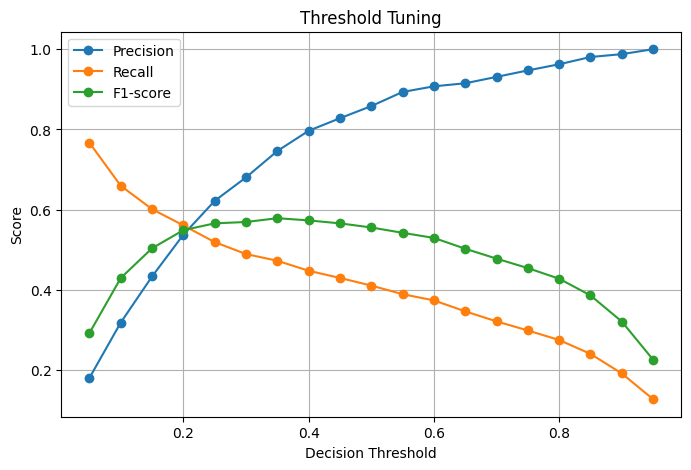

In [14]:
# 14. Plot threshold tuning results

plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="F1-score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# 15. Evaluate using the selected threshold

y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(f"Classification Report at threshold = {best_threshold:.2f}")
print(classification_report(
    y_val,
    y_pred_tuned,
    target_names=["Not Fraud", "Fraud"],
    zero_division=0
))

cm_tuned = confusion_matrix(y_val, y_pred_tuned)

print("Confusion Matrix:")
print(cm_tuned)

tn, fp, fn, tp = cm_tuned.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Classification Report at threshold = 0.35
              precision    recall  f1-score   support

   Not Fraud       0.98      0.99      0.99     23160
       Fraud       0.75      0.47      0.58       840

    accuracy                           0.98     24000
   macro avg       0.86      0.73      0.78     24000
weighted avg       0.97      0.98      0.97     24000

Confusion Matrix:
[[23025   135]
 [  443   397]]

True Negatives : 23025
False Positives: 135
False Negatives: 443
True Positives : 397


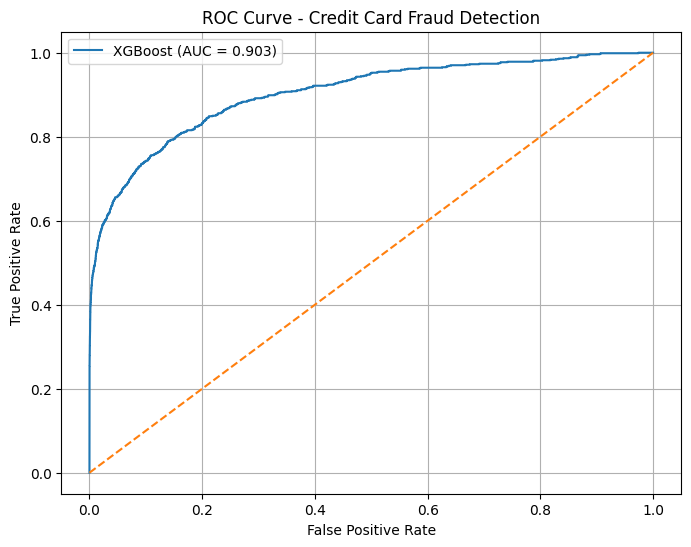

In [16]:
# 16. ROC curve

fpr, tpr, _ = roc_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

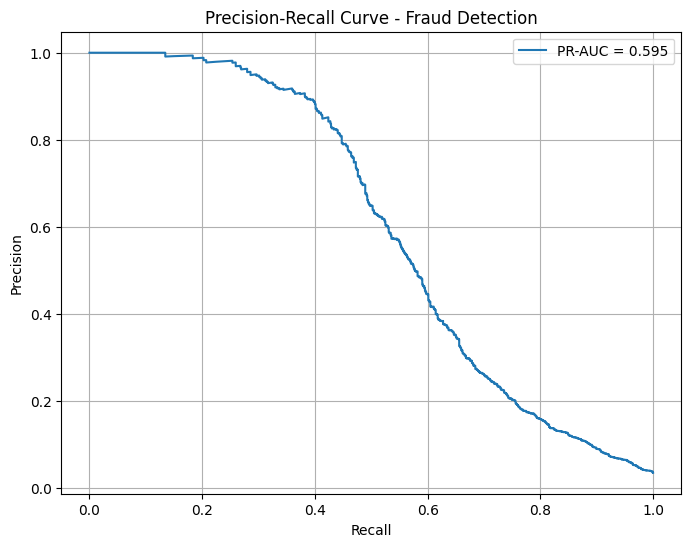

In [17]:
# 17. Precision-Recall curve

precision, recall, _ = precision_recall_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# 18. Feature importance

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 Important Features:")
print(importance_df.head(20).to_string(index=False))

Top 20 Important Features:
feature  importance
   V201    0.081517
    V34    0.054702
   V257    0.048138
    V90    0.046658
   V258    0.035940
    V94    0.023232
   V294    0.022319
   V284    0.021935
   V102    0.021816
    V29    0.019675
   V317    0.019658
    V15    0.016106
    C14    0.015428
    C12    0.015393
   V295    0.014725
    V95    0.013175
   V281    0.012858
   V306    0.012433
     C7    0.012218
   V243    0.011454


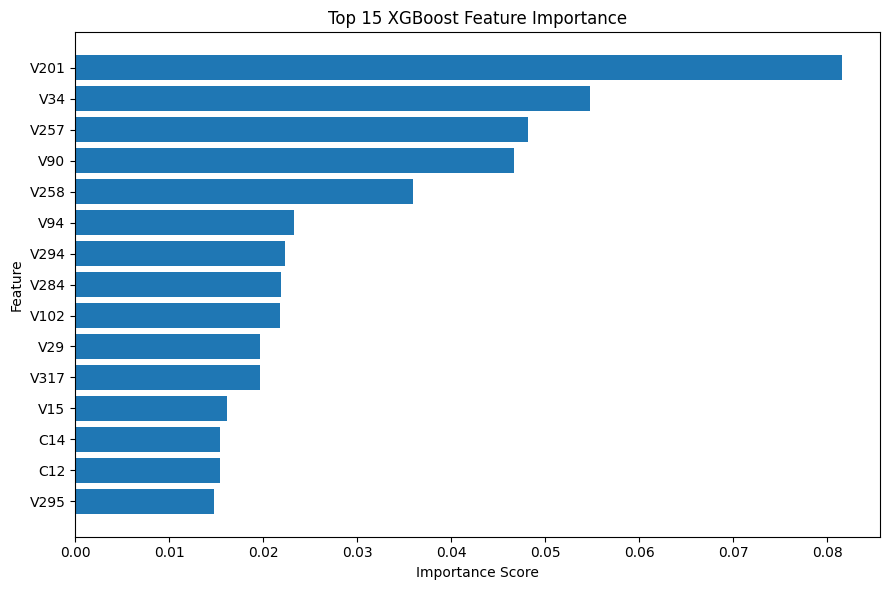

In [19]:
# 19. Plot top 15 feature importance scores

top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [20]:
# 20. Compact final summary

final_precision = precision_score(y_val, y_pred_tuned, zero_division=0)
final_recall = recall_score(y_val, y_pred_tuned, zero_division=0)
final_f1 = f1_score(y_val, y_pred_tuned, zero_division=0)

summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Decision Threshold",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        roc_auc,
        pr_auc,
        best_threshold,
        final_precision,
        final_recall,
        final_f1
    ]
})

print(summary.to_string(index=False))

            Metric    Value
           ROC-AUC 0.902590
            PR-AUC 0.595263
Decision Threshold 0.350000
         Precision 0.746241
            Recall 0.472619
          F1-Score 0.578717


In [21]:
# 21. Save predictions

predictions = pd.DataFrame({
    "actual_isFraud": y_val.reset_index(drop=True),
    "fraud_probability": y_prob,
    "predicted_isFraud": y_pred_tuned
})

predictions.to_csv("fraud_predictions.csv", index=False)

print("fraud_predictions.csv created!")
print(predictions.head())

fraud_predictions.csv created!
   actual_isFraud  fraud_probability  predicted_isFraud
0               0           0.014731                  0
1               0           0.001320                  0
2               0           0.012233                  0
3               0           0.083682                  0
4               0           0.013351                  0
